In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pyfixest as pf
import os

### Load Data

In [2]:
mp_year_topic_df = pd.read_csv("data/mp_year_topic_df.csv")
income_data = pd.read_csv("data/pp20_income_data_compatible.csv")

### Descriptive Statistics

In [3]:
plt.rcParams['text.usetex'] = True
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.size'] = 12
plt.style.use('tableau-colorblind10')

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

In [4]:
party_earnings_info = {
    'SPD': {"label": "SPD"},
    'BÜNDNIS 90/DIE GRÜNEN': {"label": "DIE GRÜNEN"},
    'CDU/CSU': {"label": "CDU/CSU"},
    'AfD': {"label": "AfD"},
    'FDP': {"label": "FDP"},
    'DIE LINKE': {"label": "DIE LINKE"}
}

for p in party_earnings_info.keys():
    moonlighting_mps_total = 0
    party_income_df = income_data[income_data.fraction == p]
    party_earnings_info[p]["earnings_total"] = party_income_df.income.sum()

    party_df = mp_year_topic_df[mp_year_topic_df.fraction_or_role == p]
    mp_group = party_df.groupby("mp")
    for mp in mp_group.groups.keys():
        g = mp_group.get_group(mp)
        if g.earnings.sum() > 0:
            moonlighting_mps_total += 1
    party_earnings_info[p]["moonlighting_mps_total"] = moonlighting_mps_total
    party_earnings_info[p]["moonlighting_mps_prop"] = moonlighting_mps_total/len(mp_group.groups.keys())

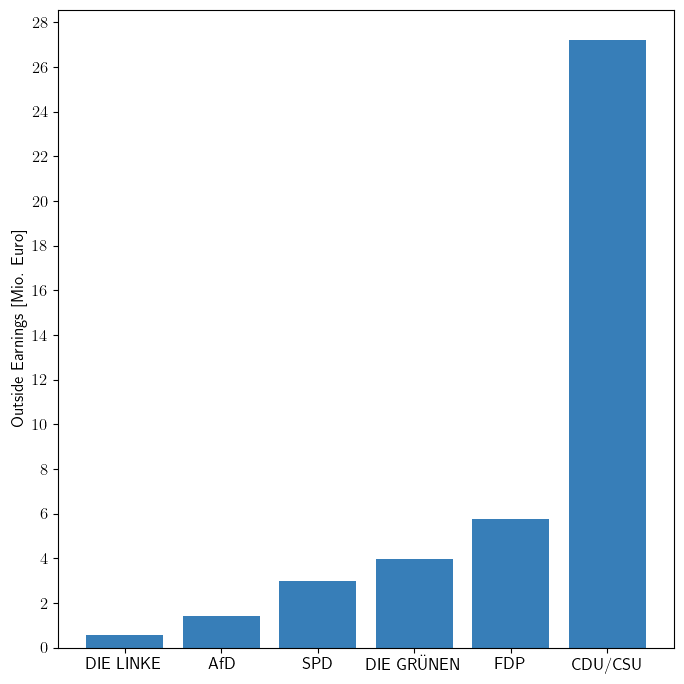

In [7]:
party_earnings_total = [(party_earnings_info[p]["label"], party_earnings_info[p]["earnings_total"]) for p in party_earnings_info.keys()]
party_earnings_total.sort(key=lambda x: x[1])
partys, earnings_total = zip(*party_earnings_total)

fig = plt.figure(figsize=(7,7))
plt.bar(partys, np.array(earnings_total)/10**6, color=CB_color_cycle[0])
plt.yticks(np.arange(0,30,2))
plt.ylabel("Outside Earnings [Mio. Euro]")
plt.tight_layout()

if not os.path.isdir("pics/"):
    os.mkdir("pics/")

plt.savefig("pics/total_earnings.pdf",format="pdf")

plt.show()

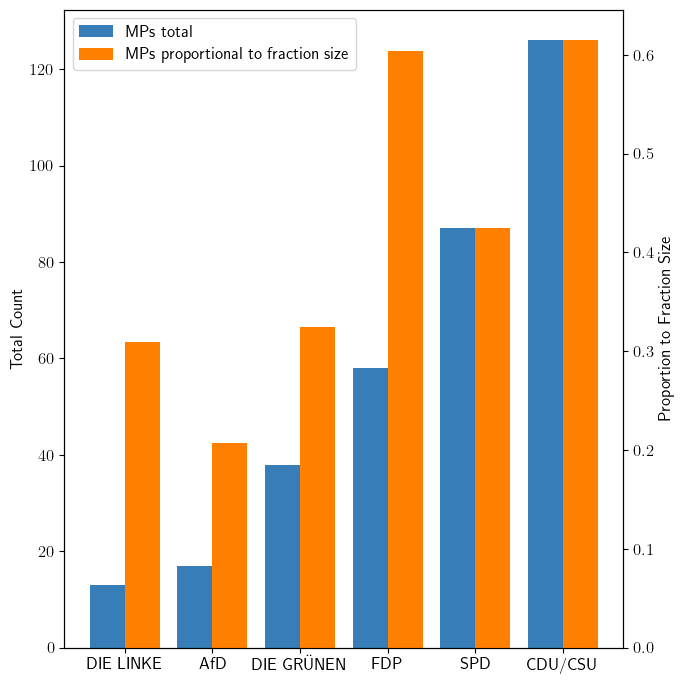

In [ ]:
party_moonlighting_mps = [(party_earnings_info[p]["label"], party_earnings_info[p]["moonlighting_mps_total"], party_earnings_info[p]["moonlighting_mps_prop"]) for p in party_earnings_info.keys()]
party_moonlighting_mps.sort(key=lambda x: x[1])
partys, moonlighting_mps_total, moonlighting_mps_prop = zip(*party_moonlighting_mps)

fig, axes = plt.subplots(figsize=(7,7))

x = np.arange(len(partys))

ax1 = axes
ax1_2 = ax1.twinx()
bars1 = ax1.bar(x-0.2, moonlighting_mps_total, width=0.4, color=CB_color_cycle[0], label="MPs total")
bars2 = ax1_2.bar(x+0.2, moonlighting_mps_prop, width=0.4, color=CB_color_cycle[1], label="MPs proportional to fraction size")

ax1.set_ylabel("Total Count")
ax1_2.set_ylabel("Proportion to Fraction Size")

ax1.set_xticks(x)
ax1.set_xticklabels(partys, rotation=0)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1_2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")
plt.tight_layout()

if not os.path.isdir("pics/"):
    os.mkdir("pics/")

plt.savefig("pics/number_of_mps_moonlighting.pdf",format="pdf")

plt.show()

### Fixed Effect Regression

In [7]:
mp_year_topic_df.earnings = mp_year_topic_df.earnings.values/100000
mp_year_topic_df.earnings_above_1000 = mp_year_topic_df.earnings_above_1000.values/100000
mp_year_topic_df.earnings_above_5000 = mp_year_topic_df.earnings_above_5000.values/100000
mp_year_topic_df.earnings_above_10000 = mp_year_topic_df.earnings_above_10000.values/100000
mp_year_topic_df.earnings_above_50000 = mp_year_topic_df.earnings_above_50000.values/100000

In [8]:
result = pf.feols("topic_share ~ earnings|year+id+mp_times_topic", 
                  vcov={"CRV1": "id"}, 
                  data=mp_year_topic_df)
print(result.summary())
pf.etable(result)

###

Estimation:  OLS
Dep. var.: topic_share, Fixed effects: year+id+mp_times_topic
Inference:  CRV1
Observations:  80800

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| earnings      |      0.037 |        0.011 |     3.259 |      0.001 |  0.015 |   0.059 |
---
RMSE: 0.097 R2: 0.5 R2 Within: 0.001 
None


GT(_tbl_data=  level_0               level_1                     0
0    coef              earnings  0.037** <br> (0.011)
1      fe                    id                     x
2      fe        mp_times_topic                     x
3      fe                  year                     x
4   stats          Observations                 80800
5   stats             S.E. type                by: id
6   stats         R<sup>2</sup>                 0.500
7   stats  R<sup>2</sup> Within                 0.001, _body=<great_tables._gt_data.Body object at 0x7f85a9aa37d0>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f85a9aa3320>, _spanners=Spanners([SpannerInfo(spanner_id='topic_share', spanner_level=1, spanner_label='topic_share', spanner_units=None, spanner_pattern=None, vars=['0'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f85a9aa3fb0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f85a9aa1e20>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f85a9aa17f0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='hidden'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', v

In [9]:
### Results for different income levels

ivs = ["earnings_above_1000", "earnings_above_5000", "earnings_above_10000", "earnings_above_50000"]

for iv in ivs:
    result = pf.feols(f"topic_share ~ {iv}|year+id+mp_times_topic", 
                    vcov={"CRV1": "id"}, 
                    data=mp_year_topic_df)
    print(f"### {iv}")
    print(f"coef: {result.coef().values}", f"se: {result.se().values}", f"p: {result.pvalue().values}")

### earnings_above_1000
coef: [0.03673069] se: [0.01129045] p: [0.00118837]
### earnings_above_5000
coef: [0.03608596] se: [0.01132681] p: [0.00149858]
### earnings_above_10000
coef: [0.03579339] se: [0.01135865] p: [0.00168603]
### earnings_above_50000
coef: [0.03450121] se: [0.01148202] p: [0.00273975]


In [10]:
### Results broken down by party

partys = ['AfD', 'CDU/CSU', 'FDP', 'BÜNDNIS 90/DIE GRÜNEN', 'SPD', 'DIE LINKE']
partys.sort()

for p in partys:
    party_df = mp_year_topic_df[mp_year_topic_df.fraction_or_role == p]
    
    result = pf.feols("topic_share ~ earnings|year+id+mp_times_topic", 
                      vcov={"CRV1": "id"}, 
                      data=party_df)
    print(f"### {p}")
    print(f"coef: {result.coef().values}", f"se: {result.se().values}", f"p: {result.pvalue().values}", f"obs.:{party_df.shape[0]}", f"MPs(n):{len(party_df.mp.unique())}")

### AfD
coef: [0.08004733] se: [0.01519509] p: [1.11376584e-06] obs.:8000 MPs(n):82


/home/til/Documents/python/powi/causal_inference/.venv/lib/python3.12/site-packages/pyfixest/estimation/model_matrix_fixest_.py:215: UserWarning: 60 singleton fixed effect(s) detected. These observations are dropped from the model.
  warnings.warn(


### BÜNDNIS 90/DIE GRÜNEN
coef: [0.30109586] se: [0.15264524] p: [0.05099279] obs.:10860 MPs(n):117


/home/til/Documents/python/powi/causal_inference/.venv/lib/python3.12/site-packages/pyfixest/estimation/model_matrix_fixest_.py:215: UserWarning: 20 singleton fixed effect(s) detected. These observations are dropped from the model.
  warnings.warn(


### CDU/CSU
coef: [0.03439045] se: [0.01203389] p: [0.00471046] obs.:20340 MPs(n):205
### DIE LINKE
coef: [-0.16045975] se: [0.09994985] p: [0.11608123] obs.:3540 MPs(n):42


/home/til/Documents/python/powi/causal_inference/.venv/lib/python3.12/site-packages/pyfixest/estimation/model_matrix_fixest_.py:215: UserWarning: 60 singleton fixed effect(s) detected. These observations are dropped from the model.
  warnings.warn(


### FDP
coef: [0.00309435] se: [0.08726844] p: [0.97179149] obs.:8940 MPs(n):96


/home/til/Documents/python/powi/causal_inference/.venv/lib/python3.12/site-packages/pyfixest/estimation/model_matrix_fixest_.py:215: UserWarning: 60 singleton fixed effect(s) detected. These observations are dropped from the model.
  warnings.warn(


### SPD
coef: [0.30812798] se: [0.10887045] p: [0.00512375] obs.:19840 MPs(n):205


#### Checking Parallel Trends

In [11]:
result = pf.feols("topic_share ~ job_entry_minus_2 + job_entry_minus_1 + in_job + job_entry_plus_1 + job_entry_plus_2|year+id+mp_times_topic", 
                  vcov={"CRV1": "id"}, 
                  data=mp_year_topic_df)
print(result.summary())

###

Estimation:  OLS
Dep. var.: topic_share, Fixed effects: year+id+mp_times_topic
Inference:  CRV1
Observations:  80800

| Coefficient       |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| job_entry_minus_2 |      0.007 |        0.012 |     0.564 |      0.573 | -0.017 |   0.031 |
| job_entry_minus_1 |      0.040 |        0.012 |     3.412 |      0.001 |  0.017 |   0.062 |
| in_job            |      0.058 |        0.013 |     4.622 |      0.000 |  0.033 |   0.082 |
| job_entry_plus_1  |      0.034 |        0.012 |     2.763 |      0.006 |  0.010 |   0.059 |
| job_entry_plus_2  |      0.005 |        0.015 |     0.297 |      0.767 | -0.026 |   0.035 |
---
RMSE: 0.097 R2: 0.5 R2 Within: 0.001 
None


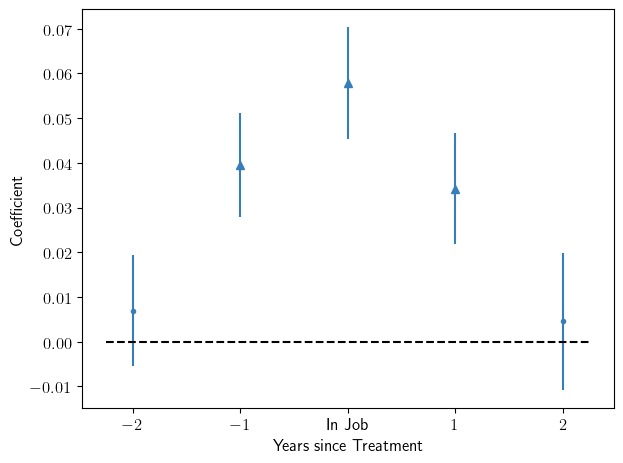

In [ ]:
x = [-2,-1,0,1,2]
coefs = result.coef().values
ses = result.se().values
ps = result.pvalue().values

for i in range(len(x)):
    if ps[i] < 0.01:
        marker = '^'
    else:
        marker = '.'
    plt.errorbar(x[i],coefs[i],yerr=ses[i],fmt=marker,color=CB_color_cycle[0])
plt.hlines(y=0, xmin=x[0]-0.25, xmax=x[-1]+0.25, linestyles='dashed', colors="black")
plt.xlabel("Years since Treatment")
plt.ylabel("Coefficient")
plt.xticks(x, ["$-2$","$-1$","In Job","$1$","$2$"])
plt.tight_layout()

if not os.path.isdir("pics/"):
    os.mkdir("pics/")

plt.savefig("pics/pre-post-treatment.pdf",format="pdf")

plt.show()

### Which sector drives the pre- and post-treatment effects?

In [13]:
import warnings
warnings.filterwarnings("ignore")

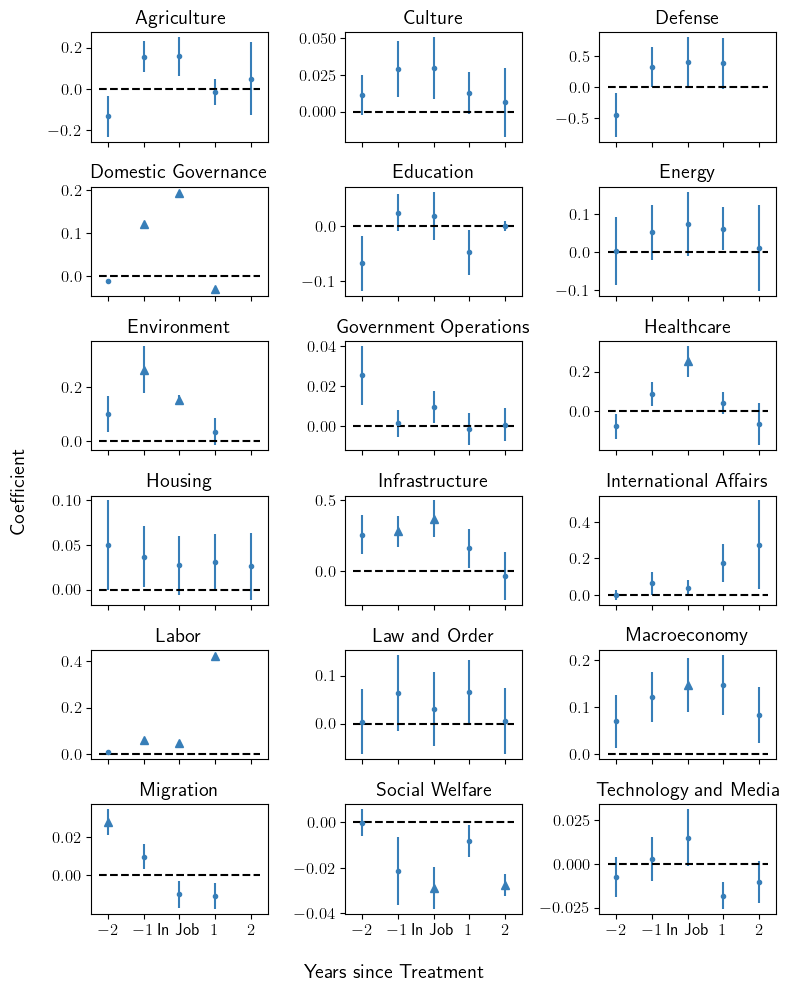

In [ ]:
sector_group = mp_year_topic_df.groupby("topic")
sector_keys = sector_group.groups.keys()
sector_keys = [key for key in sector_keys if key not in ['Civil Rights', 'Parliamentary Affairs']]

fig, axes = plt.subplots(6,3, figsize=(8,10), sharex=True, sharey=False)
axes = axes.flatten()

xmap = {
    'job_entry_minus_2': -2,
    'job_entry_minus_1': -1,
    'in_job': 0,
    'job_entry_plus_1': 1,
    'job_entry_plus_2': 2
}

for k, sector in enumerate(sector_keys):
    sg = sector_group.get_group(sector)
    
    result = pf.feols("topic_share ~ job_entry_minus_2+job_entry_minus_1+in_job+job_entry_plus_1+job_entry_plus_2|year+id+mp_times_topic", 
                  vcov={"CRV1": "id"}, 
                  data=sg)
    coefs = result.coef().values
    ses = result.se().values
    ps = result.pvalue().values
    x = [xmap[coef_name] for coef_name in list(result.tidy().index) if coef_name in xmap.keys()]

    ax = axes[k]

    for i in range(len(x)):
        if ps[i] < 0.01:
            marker = '^'
        else:
            marker = '.'
        ax.errorbar(x[i],coefs[i],yerr=ses[i],fmt=marker,color=CB_color_cycle[0])
    ax.hlines(y=0, xmin=-2-0.25, xmax=2+0.25, linestyles='dashed', colors="black")
    ax.set_xticks([-2,-1,0,1,2], ["$-2$","$-1$","In Job","$1$","$2$"])
    ax.set_title(f"{sector}")
fig.supxlabel("Years since Treatment")
fig.supylabel("Coefficient")
plt.tight_layout()

if not os.path.isdir("pics/"):
    os.mkdir("pics/")

plt.savefig("pics/pre-post-treatment-sectoral.pdf",format="pdf")

plt.show()